In [1]:
pip install arch pyvinecopulib ecos

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.4/142.4 kB 5.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 982.9/982.9 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 4.5 MB/s eta 0:00:00
  Created wheel for ecos: filename=ecos-2.0.14-cp313-cp313-linux_x86_64.whl size=203999 sha256=c86bbed9e3b0ba1977a6a011b96a39cd3717b18931fc9ef4a597d01bda3e467d
  Stored in directory: /root/.cache/pip/wheels/6b/82/0b/4bb5aa6c4618f367601a45db8710205d56858808423974e92a
Successfully built ecos


In [2]:
import os
import warnings
import numpy as np
import cvxpy as cp
import numpy as np
import pandas as pd
import yfinance as yf
import pyvinecopulib as pv
from arch import arch_model
from scipy.stats import qmc
import matplotlib.pyplot as plt
from scipy.spatial.distance import squareform
from sklearn.metrics import adjusted_rand_score
from dataclasses import dataclass, field, asdict
from scipy.stats import genpareto, kendalltau, rankdata
from scipy.cluster.hierarchy import linkage, fcluster, leaves_list
from typing import Optional, Sequence, Union, List, Dict, Any, Tuple, Literal

# Dataclasses

In [47]:
@dataclass
class ModelParams:
  distance_method:str="kendalltau"
  gap_bootstrap_samples:int=100
  cvar_q:float=0.95
  k_max:int=8
  shrink_target_ess:int=100
  shrink:bool=True
  min_effective_sample:int=30
  tail_power:float=0.8
  tail_threshold:float=0.80
  tau_shrinkage_params:float=0.20
  use_cluster_mvo:bool=True
  n_bootstrap:int = 1000
  block_size:Optional[int] = None
  seed:Optional[int]=None
  scale_factor:int=100
  sobol_pow:int = 16
  n_steps:int = 63
  lags:int = 10
  gamma_var:float = 2
  gamma_cvar:float = 2
  lambda_anchor:float = 0.5

  def __post_init__(self):
    allowed_methods = {"kendalltau", "pearsoncorr"}
    if self.distance_method not in allowed_methods:
      raise ValueError(f"Invalid status. Choose from {allowed_methods}")

    if not (0 <= self.cvar_q <= 1):
      raise ValueError("Quantile must be between 0 and 1")


In [48]:
@dataclass
class Universe:
  Bonds:List[str]
  ManagedFutures:List[str]
  Commodities:List[str]
  High_Beta:List[str]
  High_Yield:List[str]
  Low_Beta:List[str]


In [49]:
@dataclass
class ClusterParams:
  quantiles: dict[str, float] = field(default_factory=dict)
  paths: np.ndarray = None

In [50]:
@dataclass
class TailFit:
  c_L: float
  scale_L: float
  c_U: float
  scale_U: float
  p_l: float
  p_u: float
  u_lower: float
  u_upper: float
  ecdf_data: np.ndarray

In [51]:
@dataclass
class CVaRHERCParams:
  vine_structure:np.ndarray=None
  tau_prev:np.ndarray=None
  vol_init:dict = field(default_factory=dict)
  r_init:dict = field(default_factory=dict)
  best_models:dict = field(default_factory=dict)
  best_fits:dict = field(default_factory=dict)
  best_lags:dict = field(default_factory=dict)
  marginal_distributions:dict = field(default_factory=dict)
  fit:bool=False

# DataLoader

In [52]:
class DataStore:
  def __init__(self, debug:bool=False, **kwargs):
    super().__init__(
      debug=debug,
      **kwargs
    )
    self.debug = debug

  def _get_data(
      self,
      universe:dict,
      start:str,
      end:str,
      interval:str="1d",
      benchmark:str="^GSPC"
  ):
    tickers_raw = list(asdict(universe).values())
    tmp = []
    for t in tickers_raw:
      if isinstance(t, list):
        tmp.extend(t)
      elif isinstance(t, str):
        tmp.append(t)

      else:
        print(f"Warning: Skipping {t} | type: {type(t)} ")

    tickers_clean = list(set(tmp))

    self.benchmark_ticker = benchmark
    df_path = f"portfolio_{start}_{end}.parquet"

    if not os.path.exists(df_path):
      if benchmark not in tickers_clean:
        tickers_clean.append(benchmark)

      df = yf.download(tickers_clean, start, end, interval)["Close"]

      df.to_parquet(df_path)

    else:
      df = pd.read_parquet(df_path)

    bench_data = df["^GSPC"]
    data_raw = df.drop(columns=["^GSPC"])

    benchmark = bench_data.pct_change().dropna()
    returns = data_raw.pct_change().dropna()
    self.universe = data_raw.columns

    return returns, benchmark

  def plot_data(self):
    (np.cumsum(self.returns_raw * 100, axis=0) + 100).plot(figsize=(15, 10))
    plt.show()

  def plot_benchmark(self):
    (np.cumsum(self.benchmark * 100, axis=0) + 100).plot(figsize=(15, 10))
    plt.show()


# CVaR

In [53]:
class MarginalTailModel:
  def __init__(self, params, ticker):
    self.dist_p = params
    self.ticker = ticker
    self.tail_fit = None

  def fit_dist(self, r):
    full_idx = r.index
    r = r.dropna()
    valid_idx = r.index
    r = r.to_numpy(dtype=float)

    q_upper = self.dist_p.cvar_q * 100
    q_lower = (1 - self.dist_p.cvar_q) * 100

    u_upper = np.percentile(r, q_upper)
    u_lower = np.percentile(r, q_lower)

    upper_tail = r[r > u_upper]
    lower_tail = r[r < u_lower]

    if len(upper_tail) == 0 or len(lower_tail) == 0:
      raise ValueError(f"{self.ticker}: insufficient observations in EVT tail.")

    c_U, _, scale_U = genpareto.fit(upper_tail - u_upper, floc=0)
    c_L, _, scale_L = genpareto.fit(u_lower - lower_tail, floc=0)

    if c_L >= 1.0:
      warnings.warn(
        f"{self.ticker}: lower-tail GPD xi={c_L:.4f} >= 1. "
        "The fitted tail has infinite mean, so theoretical CVaR/ES is not finite.",
        RuntimeWarning,
      )
    elif c_L >= 0.5:
      warnings.warn(
        f"{self.ticker}: lower-tail GPD xi={c_L:.4f} is very heavy. "
        "CVaR can converge slowly even with QMC.",
        RuntimeWarning,
      )

    p_l = np.mean(r < u_lower)
    p_u = np.mean(r > u_upper)

    lower_mask = r < u_lower
    upper_mask = r > u_upper
    body_mask = (~lower_mask) & (~upper_mask)

    u_resid = np.zeros_like(r, dtype=float)

    if np.any(lower_mask):
      cdf_l = 1 - genpareto.cdf(
        u_lower - r[lower_mask], c_L, loc=0, scale=scale_L
      )
      u_resid[lower_mask] = p_l * cdf_l

    if np.any(body_mask):
      body = r[body_mask]
      ranks = pd.Series(body).rank(method="average").to_numpy()
      cdf_b = p_l + (1 - p_l - p_u) * (ranks / (len(body) + 1))
      u_resid[body_mask] = cdf_b

    if np.any(upper_mask):
      cdf_u = (1 - p_u) + p_u * genpareto.cdf(
        r[upper_mask] - u_upper, c_U, loc=0, scale=scale_U
      )
      u_resid[upper_mask] = cdf_u

    self.tail_fit = TailFit(
      c_L=c_L,
      scale_L=scale_L,
      c_U=c_U,
      scale_U=scale_U,
      p_l=p_l,
      p_u=p_u,
      u_lower=u_lower,
      u_upper=u_upper,
      ecdf_data=r[(r >= u_lower) & (r <= u_upper)],
    )

    u_resid_full = pd.Series(np.nan, index=full_idx, dtype=float)
    u_resid_full.loc[valid_idx] = u_resid
    return u_resid_full

  def inverse_cdf(self, u_resid):
    z_resid_final = np.zeros_like(u_resid, dtype=float)

    for i in range(u_resid.shape[1]):
      u_resid_i = u_resid[:, i]
      real_col = np.zeros_like(u_resid_i)

      p_u = self.tail_fit.p_u
      p_l = self.tail_fit.p_l
      u_upper = self.tail_fit.u_upper
      u_lower = self.tail_fit.u_lower

      lower_mask = u_resid_i < p_l
      upper_mask = u_resid_i > (1 - p_u)
      body_mask = (~lower_mask) & (~upper_mask)

      if np.any(upper_mask):
        q = (u_resid_i[upper_mask] - (1 - p_u)) / p_u
        real_col[upper_mask] = (
          u_upper
          + genpareto.ppf(
            q,
            self.tail_fit.c_U,
            loc=0,
            scale=self.tail_fit.scale_U,
          )
        )

      if np.any(body_mask):
        body_q = (
          (u_resid_i[body_mask] - p_l)
          / (1 - p_l - p_u)
          * 100
        )
        real_col[body_mask] = np.percentile(
          self.tail_fit.ecdf_data,
          np.clip(body_q, 0, 100),
        )

      if np.any(lower_mask):
        q = 1 - u_resid_i[lower_mask] / p_l
        real_col[lower_mask] = (
          u_lower
          - genpareto.ppf(
            q,
            self.tail_fit.c_L,
            loc=0,
            scale=self.tail_fit.scale_L,
          )
      )

      z_resid_final[:, i] = real_col

    return z_resid_final

In [54]:
class GARCHEVTCOPULA:
  def __init__(self, params, debug=False, **kwargs):
    self.debug = debug
    self.model_p = params
    self.sobol_seed = params.seed

  @staticmethod
  def _fit_arch(model, warm_start_params):
    fit_kwargs = dict(disp="off", show_warning=False)
    if warm_start_params is not None:
      try:
        return model.fit(
          starting_values=np.asarray(warm_start_params, dtype=float),
          **fit_kwargs,
        )
      except (ValueError, TypeError, np.linalg.LinAlgError):
        pass
    return model.fit(**fit_kwargs)

  def _fit_model(
      self,
      r,
      ticker=None,
      warm_start_params=None,
      warm_start_lags=None,
  ):
    best_bic = np.inf
    best_model = best_fit = best_lags = None

    lag_candidates = (
      [warm_start_lags]
      if warm_start_lags is not None
      else range(1, self.model_p.lags + 1)
    )

    for lags in lag_candidates:
      model = arch_model(
        r,
        mean="AR",
        lags=lags,
        vol="GARCH",
        p=1,
        o=1,
        q=1,
        dist="studentst",
      )

      fit = self._fit_arch(model, warm_start_params)

      if fit.convergence_flag:
        continue

      alpha = fit.params["alpha[1]"]
      gamma = fit.params["gamma[1]"]
      beta = fit.params["beta[1]"]

      if alpha + beta + 0.5 * gamma < 1 and fit.bic < best_bic:
        best_bic = fit.bic
        best_model, best_fit, best_lags = model, fit, lags

    if best_model is None:
      for lags in lag_candidates:
        model = arch_model(
          r,
          mean="AR",
          lags=lags,
          vol="GARCH",
          p=1,
          o=0,
          q=1,
          dist="studentst",
        )
        fit = self._fit_arch(model, None)

        if fit.convergence_flag:
          continue

        alpha = fit.params["alpha[1]"]
        beta = fit.params["beta[1]"]

        if self.debug:
          print("GARCH persistence:", alpha + beta)

        if alpha + beta < 1 and fit.bic < best_bic:
            best_bic = fit.bic
            best_model, best_fit, best_lags = model, fit, lags

    if best_model is None:
      raise ValueError("No stationary GARCH fit found")

    return best_model, best_fit, best_lags

  def _fit_arma_garch(self, returns):
    if self.debug:
      print("------------- Fitting AR-GARCH -------------")

    log_returns = np.log1p(returns)
    filtered_resid = pd.DataFrame(
      index=returns.index,
      columns=returns.columns,
      dtype=float,
    )
    cols = returns.columns

    warm_start = bool(self.model_fit.fit)

    if not hasattr(self.model_fit, "ar_history"):
      self.model_fit.ar_history = {}

    for i, col in enumerate(cols):
      if self.debug:
        print(f"Fitting {col} | {i + 1}/{len(cols)}")

      r_scaled = (log_returns[col] * self.model_p.scale_factor).dropna()

      warm_params, warm_lags = None, None
      if warm_start and col in self.model_fit.best_fits:
        warm_params = self.model_fit.best_fits[col].params
        warm_lags = self.model_fit.best_lags[col]

      best_model, best_fit, best_lags = self._fit_model(
        r_scaled,
        ticker=col,
        warm_start_params=warm_params,
        warm_start_lags=warm_lags,
      )

      self.model_fit.best_models[col] = best_model
      self.model_fit.best_fits[col] = best_fit
      self.model_fit.best_lags[col] = best_lags

      hist = r_scaled.to_numpy(dtype=float)
      if hist.size < best_lags:
        raise ValueError(
          f"{col}: need at least {best_lags} observations "
          "to initialize AR recursion."
        )
      self.model_fit.ar_history[col] = hist[-best_lags:].copy()
      self.model_fit.vol_init[col] = np.asarray(
        best_fit.conditional_volatility,
        dtype=float
      )[-1]

      self.model_fit.r_init[col] = hist[-1]

      resid = pd.Series(best_fit.std_resid, index=r_scaled.index)
      filtered_resid.loc[resid.index, col] = resid

    return filtered_resid

  def _get_uniform_residuals(self, residuals):
      if self.debug:
        print("------------ Uniform Residuals -------------")

      u_resid = pd.DataFrame(
        index=residuals.index,
        columns=residuals.columns,
        dtype=float,
      )

      for ticker in residuals.columns:
        model = MarginalTailModel(self.model_p, ticker)
        u_resid_i = model.fit_dist(residuals[ticker])
        u_resid[ticker] = u_resid_i
        self.model_fit.marginal_distributions[ticker] = model

      return u_resid

  def _inverse_semi_parametric_cdf(self, uniform_samples):
    if self.debug:
      print("-------- Inverse Semi Parametric CDF -------")

    n_paths, n_steps, n_assets = uniform_samples.shape
    z_resid = np.zeros(
      (n_paths, n_steps, n_assets),
      dtype=float,
    )

    eps = 1e-6

    for asset_idx, ticker in enumerate(self.cols):
      model = self.model_fit.marginal_distributions[ticker]

      u_slice = uniform_samples[:, :, asset_idx].T
      u_slice = np.clip(u_slice, eps, 1 - eps)

      z_slice = model.inverse_cdf(u_slice)
      z_resid[:, :, asset_idx] = z_slice.T

    return z_resid

  def _fit_vine_copula(self, u_resid, structure=None):
    if self.debug:
      print("----------- Fitting Vine Copula ------------")

    clean = u_resid.dropna(how="any")

    if clean.empty:
      raise ValueError("No complete residual rows available for vine fit.")

    eps = 1e-10
    np_resid = np.asfortranarray(
      np.clip(clean.to_numpy(dtype=float), eps, 1 - eps),
      dtype=np.float64,
    )

    controls = pv.FitControlsVinecop()
    self.copula = pv.Vinecop.from_data(
      u=np_resid,
      controls=controls,
      structure=structure,
    )

  def fit(self, returns, fit_params):
    self.model_fit = fit_params

    z_resid = self._fit_arma_garch(returns)
    self.cols = z_resid.columns
    self.start = z_resid.index[0]
    self.end = z_resid.index[-1]

    u_resid = self._get_uniform_residuals(z_resid)

    structure = (
      self.model_fit.vine_structure
      if self.model_fit.fit
      else None
    )
    self._fit_vine_copula(u_resid, structure=structure)

    self.model_fit.vine_structure = self.copula.structure
    self.model_fit.fit = True

    return self.model_fit

  def _ar_coefficients(self, params, ticker, p):
    coeffs = np.empty(p, dtype=float)

    for lag in range(1, p + 1):
      key = f"{ticker}[{lag}]"
      if key not in params.index:
        raise KeyError(
          f"Expected AR parameter '{key}' not found. "
          f"Available parameters: {list(params.index)}"
        )
      coeffs[lag - 1] = float(params[key])

    return coeffs

  def _convert_to_returns(self, sim_r, model, params, ticker):
    if self.debug:
      print(f"------ Converting {ticker} to Returns -----")

    n_paths, n_steps = sim_r.shape
    p = int(self.model_fit.best_lags[ticker])

    const = float(params.get("Const", 0.0))
    phi = self._ar_coefficients(params, ticker, p)

    omega = float(params["omega"])
    alpha = float(params["alpha[1]"])
    gamma = float(params.get("gamma[1]", 0.0))
    beta = float(params["beta[1]"])

    fit = self.model_fit.best_fits[ticker]

    sigma_prev = fit.conditional_volatility[-1]
    eps_prev_scalar = fit.resid[-1]

    sigma2_prev = np.full(
      n_paths,
      sigma_prev ** 2,
      dtype=float,
    )
    eps_prev = np.full(
      n_paths,
      eps_prev_scalar,
      dtype=float,
    )

    hist_1d = np.asarray(
      self.model_fit.ar_history[ticker],
      dtype=float,
    )
    if hist_1d.size != p:
      raise ValueError(
          f"{ticker}: AR history size {hist_1d.size} != selected p={p}"
      )

    r_hist = np.tile(hist_1d, (n_paths, 1))

    r_t = np.zeros_like(sim_r, dtype=float)

    for t in range(n_steps):
      I_prev = (eps_prev < 0.0).astype(float)

      sigma2_t = (
        omega
        + (alpha + gamma * I_prev) * eps_prev ** 2
        + beta * sigma2_prev
      )

      sigma2_t = np.maximum(sigma2_t, 1e-14)

      eps_t = np.sqrt(sigma2_t) * sim_r[:, t]

      ar_term = np.zeros(n_paths, dtype=float)
      for lag in range(1, p + 1):
        ar_term += phi[lag - 1] * r_hist[:, -lag]

      mu_t = const + ar_term
      r_current = mu_t + eps_t
      r_t[:, t] = r_current

      if p > 1:
        r_hist[:, :-1] = r_hist[:, 1:]
      r_hist[:, -1] = r_current

      sigma2_prev = sigma2_t
      eps_prev = eps_t

    return r_t

  def _simulate(self, n_assets):
    n_steps = self.model_p.n_steps
    m = self.model_p.sobol_pow
    n_scenarios = 2 ** m
    d = n_steps * n_assets

    sobol_engine = qmc.Sobol(
      d=d,
      scramble=True,
      seed=self.sobol_seed,
    )

    base_uniforms = sobol_engine.random_base2(m=m)
    base_uniforms = base_uniforms.reshape(
      n_scenarios,
      n_steps,
      n_assets,
    )

    eps = 1e-12
    base_uniforms = np.clip(base_uniforms, eps, 1 - eps)

    copula_uniforms = np.empty_like(base_uniforms)

    for t in range(n_steps):
      u_t = np.asfortranarray(
        base_uniforms[:, t, :],
        dtype=np.float64,
      )
      copula_uniforms[:, t, :] = (
        self.copula.inverse_rosenblatt(u_t)
      )

    return copula_uniforms

  def generate_sample(self):
    if self.debug:
      print("------------ Generating Samples ------------")

    n_assets = len(self.cols)
    simulated_uniforms = self._simulate(n_assets)

    sim_resid = self._inverse_semi_parametric_cdf(
        simulated_uniforms
    )
    sim_resid_T = np.transpose(sim_resid, (0, 2, 1))

    sim_r_log = np.zeros_like(sim_resid_T)

    for i, ticker in enumerate(self.cols):
      params = self.model_fit.best_fits[ticker].params
      model = self.model_fit.best_models[ticker]

      log_paths = (
        self._convert_to_returns(
          sim_resid_T[:, i, :],
          model,
          params,
          ticker,
        )
        / self.model_p.scale_factor
      )

      sim_r_log[:, i, :] = log_paths

    sim_r = np.expm1(sim_r_log)

    if not np.all(np.isfinite(sim_r)):
      raise FloatingPointError(
        "Simulation produced NaN/inf returns. "
        "Inspect EVT xi and GARCH path diagnostics."
      )

    return sim_r

In [55]:
class CVaR(GARCHEVTCOPULA):
  def __init__(
      self,
      params: ModelParams,
      debug: bool = False,
      **kwargs,
  ):
    super().__init__(
      debug=debug,
      params=params,
      **kwargs,
    )

    self.debug = debug
    self.cvar_p = params

    self.sobol_seed = params.seed
    self.sim_path = None

  def _make_sim_path(self):
    seed_label = (
      "random"
      if self.sobol_seed is None
      else str(self.sobol_seed)
    )

    return (
      f"simulation_{self.start}_{self.end}"
      f"_steps{self.model_p.n_steps}"
      f"_sobol2p{self.model_p.sobol_pow}"
      f"_ql{self.model_p.cvar_q:g}"
      f"_qu{self.model_p.cvar_q:g}"
      f"_seed{seed_label}.npy"
    )

  def fit_garch_evt_copula(self, returns, fit_params):
    self.start = returns.index[0]
    self.end = returns.index[-1]
    self.universe = returns.columns

    if not bool(fit_params.fit):
      fit_params = self.fit(returns, fit_params)
      self.sim_path = self._make_sim_path()
    else:
      self.model_fit = fit_params
      self.cols = returns.columns

    return fit_params

  def generate_r_sample(self, force_resimulate=False):
      if self.sim_path is None:
        raise ValueError("Fit the model first!")

      may_use_cache = (
        self.sobol_seed is not None
        and not force_resimulate
        and os.path.exists(self.sim_path)
      )

      if may_use_cache:
        return np.load(self.sim_path)

      sim_returns = self.generate_sample()

      if self.sobol_seed is not None:
        np.save(self.sim_path, sim_returns)

      return sim_returns

  def verify_cvar(
    self,
    horizon_returns,
    w,
    b,
  ):
    R = np.asarray(horizon_returns, dtype=float)

    w = np.asarray(w, dtype=float).ravel()

    b = np.asarray(b, dtype=float ).ravel()

    b /= b.sum()

    asset_L = -R
    portfolio_L = asset_L @ w

    S = len(portfolio_L)
    tail_mass =  (1.0 - self.p.cvar_q) * S

    order = np.argsort(portfolio_L)[::-1]

    L_sorted = portfolio_L[order]
    asset_L_sorted = asset_L[order]

    k = int(np.floor(tail_mass))
    frac = tail_mass - k

    if k == 0:
      raise ValueError(
        "Not enough scenarios for CVaR level."
      )

    weighted_loss_sum = np.sum(
      L_sorted[:k]
    )

    weighted_asset_sum = np.sum(
      asset_L_sorted[:k],
      axis=0
    )

    if frac > 0:
      weighted_loss_sum += frac * L_sorted[k]
      weighted_asset_sum += frac * asset_L_sorted[k]

    cvar = weighted_loss_sum / tail_mass

    mcvar = weighted_asset_sum / tail_mass

    RC = w * mcvar
    realized_budget = RC / cvar

    print("w:               ", w)
    print("MCVaR:           ", mcvar)
    print("RC:              ", RC)
    print("CVaR:            ", cvar)
    print("Euler sum:       ", RC.sum())
    print("target budget:   ", b)
    print("realized budget: ", realized_budget)
    print(
        "Max budget error:",
        np.max(
            np.abs(realized_budget - b)
        )
    )

    return mcvar, cvar

# Cluster

In [56]:
class TailWeightedKendall:
  def __init__(
    self,
    params,
    **kwargs
  ):
    super().__init__(params=params, **kwargs)
    if not 0.0 < params.tail_threshold < 1.0:
      raise ValueError(
        "tail_threshold must lie between 0 and 1."
      )

    if params.tail_power <= 0:
      raise ValueError(
        "tail_power must be positive."
      )

    self.tail_threshold = params.tail_threshold
    self.tail_power = params.tail_power

    self.min_effective_sample = params.min_effective_sample

    self.shrink = params.shrink
    self.shrink_target_ess = params.shrink_target_ess
    self.tau_shrinkage_params = params.tau_shrinkage_params

    if self.shrink_target_ess <= self.min_effective_sample:
      raise ValueError(
        "shrink_target_ess must exceed "
        "min_effective_sample"
      )

    if not 0 <= self.tau_shrinkage_params <= 1:
      raise ValueError(
        "tau_shrinkage_params must lie in [0,1]"
      )

  @staticmethod
  def compound_returns(sim_returns):
    sim_returns = np.asarray(
      sim_returns,
      dtype=float
    )
    if sim_returns.ndim != 3:
      raise ValueError(
        "sim_returns must have shape "
        "(n_paths, n_assets, n_steps)."
      )

    return (
        np.prod(1.0 + sim_returns, axis=2) - 1.0
    )

  @staticmethod
  def empirical_uniforms(losses):
    losses = np.asarray(
      losses,
      dtype=float
    )

    if losses.ndim != 2:
      raise ValueError(
        "losses must be two-dimensional."
      )

    n_paths, n_assets = losses.shape

    U = np.empty_like(
      losses,
      dtype=float
    )

    for i in range(n_assets):
      U[:, i] = (
        rankdata(
          losses[:, i],
          method="average"
        ) / (n_paths + 1.0)
      )

    return U

  def tail_weight(self, u):
    u = np.asarray(u, dtype=float)

    z = np.maximum(
      (u - self.tail_threshold) / (1.0 - self.tail_threshold),
      0.0
    )

    return z ** self.tail_power

  @staticmethod
  def effective_sample_size(weights):
    weights = np.asarray(weights, dtype=float)

    s1 = weights.sum()
    s2 = np.sum(weights ** 2)

    if s2 <= 0:
        return 0.0

    return (s1 ** 2) / s2

  @staticmethod
  def _weighted_kendall(x, y, obs_weights):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    w = np.asarray(obs_weights, dtype=float)

    n = len(x)
    if n < 2:
      return np.nan

    numerator = 0.0
    denominator = 0.0

    for p in range(n - 1):
      dx = x[p] - x[p + 1:]
      dy = y[p] - y[p + 1:]

      pair_weights = (w[p] * w[p + 1:])

      signs = np.sign(dx * dy)

      numerator += np.sum(pair_weights * signs)

      denominator += np.sum(pair_weights)

    if denominator <= 0:
      return np.nan

    return numerator / denominator

  def pair_tau(self, losses_i, losses_j, U_i, U_j):
    wi = self.tail_weight(U_i)
    wj = self.tail_weight(U_j)
    pair_weights = wi * wj
    mask = pair_weights > 0
    n_tail = int(mask.sum())

    tau_global, _ = kendalltau(losses_i, losses_j)
    if not np.isfinite(tau_global):
      tau_global = 0.0

    if n_tail < 2:
      return {
        "tau_tail": np.nan,
        "tau_global": tau_global,
        "tau_final": np.clip(tau_global, -1.0, 1.0),
        "ess": 0.0,
        "n_tail": n_tail,
      }

    x = losses_i[mask]
    y = losses_j[mask]
    w = pair_weights[mask]

    ess = self.effective_sample_size(w)
    tau_tail = self._weighted_kendall(x, y, w)

    if self.shrink and np.isfinite(tau_tail):
      if ess < self.min_effective_sample:
        tau_final = tau_global
      else:
        gamma = np.clip(
            (ess - self.min_effective_sample)
            / (self.shrink_target_ess - self.min_effective_sample),
            0.0,
            1.0,
          )

        tau_final = (
          gamma * tau_tail
          + (1.0 - gamma) * tau_global
        )

    else:
        tau_final = tau_tail if np.isfinite(tau_tail) else tau_global

    if not np.isfinite(tau_final):
        tau_final = 0.0

    tau_final = np.clip(tau_final, -1.0, 1.0)

    return {
        "tau_tail": tau_tail,
        "tau_global": tau_global,
        "tau_final": tau_final,
        "ess": ess,
        "n_tail": n_tail,
    }

  def fit_kendall(
    self,
    returns,
    assets=None,
    tau_prev=None,
    return_tau=False
  ):
    horizon_returns = self.compound_returns(returns)

    losses = -horizon_returns

    n_paths, n_assets = losses.shape

    if assets is None:
      assets = [
        f"asset_{i}"
        for i in range(n_assets)
      ]

    if len(assets) != n_assets:
      raise ValueError(
        "len(assets) must equal "
        "returns.shape[1]."
      )

    U = self.empirical_uniforms(losses)

    tau = np.eye(n_assets, dtype=float)
    tau_tail = np.eye(n_assets, dtype=float)
    tau_global = np.eye(n_assets, dtype=float)
    ess = np.zeros((n_assets, n_assets), dtype=float)
    n_tail = np.zeros((n_assets, n_assets), dtype=int)

    for i in range(n_assets):
      ess[i, i] = n_paths
      n_tail[i, i] = n_paths

      for j in range(i + 1, n_assets):
        result = self.pair_tau(losses[:, i], losses[:, j], U[:, i], U[:, j])

        tau[i, j] = result[ "tau_final"]
        tau[j, i] = tau[i, j]
        tau_tail[i, j] = result["tau_tail"]
        tau_tail[j, i] = tau_tail[i, j]
        tau_global[i, j] = result["tau_global"]
        tau_global[j, i] = tau_global[i, j]

        ess[i, j] = result["ess"]
        ess[j, i] = ess[i, j]

        n_tail[i, j] = result[ "n_tail"]
        n_tail[j, i] = n_tail[i, j]

    if tau_prev is not None:
      if tau_prev.shape != tau.shape:
        raise ValueError("tau_prev shape mismatch")

      rho = self.tau_shrinkage_params
      tau_out = tau * (1.0 - rho) + tau_prev * rho

    else:
      tau_out = tau

    distance = np.sqrt(
      0.5 * (1.0 - np.clip(tau_out, -1.0, 1.0))
    )

    np.fill_diagonal(distance, 0.0)
    dist_out = pd.DataFrame(distance, index=assets, columns=assets)

    if return_tau:
      tau_out_df = pd.DataFrame(tau_out, index=assets, columns=assets)
      output = (dist_out, tau_out_df)
    else:
      output = dist_out

    return output

  def get_tau_dist(
      self,
      returns,
      assets=None,
      tau_prev=None,
      return_tau=False
  ):
    dist_mtx = self.fit_kendall(
      returns=returns,
      assets=assets,
      tau_prev=tau_prev,
      return_tau=return_tau
    )
    return dist_mtx

In [57]:
class ClusterEngine(TailWeightedKendall):
  def __init__(self, params: ModelParams, debug=False, **kwargs):
    super().__init__(
      params=params,
      debug=debug,
      **kwargs
    )
    self.cp = ClusterParams()
    self.p = params

  def get_dist_mtx(
      self,
      returns:np.ndarray|pd.DataFrame,
      assets=None,
      tau_prev=None,
      return_tau=False
  ):
    if self.p.distance_method == "kendalltau":
      assert assets is not None, "Assets must be provided for Kendall Tau"
      dist_mtx = self.get_tau_dist(returns, assets, tau_prev, return_tau)

    elif self.p.distance_method == "pearsoncorr":
      assert returns.ndim == 2, "Returns must be two-dimensional"
      corr_mtx = np.clip(np.corrcoef(returns, rowvar=False), -1.0, 1.0)
      dist_mtx = np.sqrt(0.5 * (1 - corr_mtx))

    return dist_mtx

  def _generate_null_dists(self, sim_returns, risk_horizon, assets):
    n_paths, n_assets, n_steps = sim_returns.shape
    n_refs = self.p.gap_bootstrap_samples
    rng = np.random.default_rng()

    if sim_returns.ndim != 3:
      raise ValueError(
        "sim_returns must have shape "
        "(n_paths, n_assets, n_steps)"
      )

    null_dists, null_links = [], []

    for i in range(n_refs):
      null_returns = np.empty_like(sim_returns)

      for j in range(n_assets):
        perm = rng.permutation(n_paths)

        null_returns[:, j, :] = (
            sim_returns[perm, j, :]
        )

      null_dist = self.get_dist_mtx(
        null_returns,
        assets,
      )

      condensed_dist = squareform(null_dist.to_numpy(), checks=False)
      Z_null = linkage(condensed_dist, method="average")

      null_dists.append(null_dist)
      null_links.append(Z_null)

    return np.array(null_dists), np.array(null_links)

  def _compute_cl_dispersion(self, dist_mtx, cluster_labels):
    if isinstance(dist_mtx, pd.DataFrame):
      dist_mtx = dist_mtx.to_numpy()

    unique_clusters = np.unique(cluster_labels)
    W_k = 0.0

    for c_id in unique_clusters:
      cluster_indices = np.where(cluster_labels == c_id)[0]
      cluster_dist = dist_mtx[np.ix_(cluster_indices, cluster_indices)]

      norm = 2*len(cluster_indices)

      D_r = np.sum(cluster_dist**2)

      W_k += D_r / norm

    return W_k

  def _compute_ref_log_disp(self, null_dists, null_links, k):
    n_refs = len(null_dists)
    W_k_log = []

    for ref_i in range(n_refs):
      clusters = fcluster(null_links[ref_i], t=k, criterion="maxclust")

      W_k = self._compute_cl_dispersion(null_dists[ref_i], clusters)
      W_k_log.append(np.log(max(W_k, 1e-300)))

    W_k_log = np.array(W_k_log)
    E_W_k = np.mean(W_k_log)

    sdk = np.std(W_k_log, ddof=1) if n_refs > 1 else 0.0
    s_k = sdk * np.sqrt(1+1/n_refs)

    return E_W_k, s_k

  def _get_k_clusters(self, dist_mtx, Z, sim_returns, risk_horizon, assets):
    if self.debug:
      print("---------- Calculating K Clusters ----------")

    k_max = min(self.p.k_max, dist_mtx.shape[0]-1)
    Gap_k, s_k_list = [], []
    null_dists, null_links = self._generate_null_dists(sim_returns, risk_horizon, assets)
    k_range = list(range(1, k_max+1))

    for k in k_range:
      clusters = fcluster(Z, t=k, criterion="maxclust")

      W_k_real = self._compute_cl_dispersion(dist_mtx, clusters)
      log_disp_k = np.log(max(W_k_real, 1e-300))

      E_W_k, s_k = self._compute_ref_log_disp(null_dists, null_links, k)

      Gap_k.append(E_W_k - log_disp_k)
      s_k_list.append(s_k)

    gaps = np.array(Gap_k)
    s_k_list = np.array(s_k_list)

    optimal_k = k_range[np.argmax(gaps)]
    for idx in range(len(k_range)-1):
      if gaps[idx] >= gaps[idx+1] - s_k_list[idx+1]:
        optimal_k = k_range[idx]
        break

    if self.debug:
      print(f"Optimal k: {optimal_k}")
    return int(optimal_k)


  def get_clusters(
      self,
      dist_mtx:pd.DataFrame,
      sim_returns:np.ndarray,
      risk_horizon:int,
      assets:list
  ) -> pd.DataFrame:

    comp_disp = squareform(dist_mtx, checks=False)
    Z = linkage(comp_disp, method="average")

    optimal_k = self._get_k_clusters(dist_mtx, Z, sim_returns, risk_horizon, assets)
    labels = fcluster(Z, t=optimal_k, criterion="maxclust")

    return pd.DataFrame({'Asset': assets, 'Cluster': labels}), Z

  def _cluster_at_k(self, dist_mtx, k):
    comp_disp = squareform(dist_mtx, checks=False)
    Z = linkage(comp_disp, method="average")
    return fcluster(Z, t=k, criterion="maxclust")


  def _order_cluster_ids(self, Z, clusters_df):
    label_by_asset = clusters_df.set_index("Asset")["Cluster"]
    leaf_order = leaves_list(Z)

    asset_order = clusters_df["Asset"].values[leaf_order]
    ordered_labels = label_by_asset.loc[asset_order].values

    seen, ordered_ids = set(), []
    for lbl in ordered_labels:
      if lbl not in seen:
        seen.add(lbl)
        ordered_ids.append(lbl)

    return ordered_ids

# Bootstrap Engine

In [16]:
class BootstrapEngine:
  def __init__(self, params, debug=False, **kwargs):
    super().__init__(
        params=params,
        debug=debug,
        **kwargs
    )
    self.bootstrap_p = params
    self.debug = debug

  def run_bootstrap(self, returns):
    if self.debug:
      print("------ Running a Bootstrap Simulation ------")

    if returns is None:
      raise RuntimeError("Call .run(returns) before .bootstrap_metrics().")

    r = returns.values
    T = len(r)
    block_size = self.bootstrap_p.block_size or max(int(np.sqrt(T)), 2)
    rng = np.random.default_rng(self.bootstrap_p.seed)


    for i in range(self.bootstrap_p.n_bootstrap):
      idx = self._resample_indices(T, block_size, rng)

  def _resample_indices(self, T: int, block_size: int, rng: np.random.Generator) -> np.ndarray:
      return self._stationary_bootstrap_indices(T, block_size, rng)

  @staticmethod
  def _stationary_bootstrap_indices(T: int, block_size: int, rng: np.random.Generator) -> np.ndarray:
    p = 1.0 / block_size
    indices = np.empty(T, dtype=int)
    idx = rng.integers(0, T)

    for t in range(T):
      indices[t] = idx
      idx = rng.integers(0, T) if rng.random() < p else (idx + 1) % T

    return indices

  def bootstrap_cluster_stability(self, sim_returns, assets, baseline_labels, k, alpha=0.05):
    n_paths = sim_returns.shape[0]
    block_size = self.bootstrap_p.block_size or max(int(np.sqrt(n_paths)), 2)
    rng = np.random.default_rng(self.bootstrap_p.seed)

    tau_prev_snapshot = getattr(self, "tau_prev", None)
    aris = np.empty(self.bootstrap_p.n_bootstrap, dtype=float)

    try:
      for b in range(self.bootstrap_p.n_bootstrap):
        self.tau_prev = tau_prev_snapshot
        idx = self._resample_indices(n_paths, block_size, rng)
        resampled_paths = sim_returns[idx]

        dist_mtx_b, = self.get_dist_mtx(resampled_paths, assets)
        labels_b = self._cluster_at_k(dist_mtx_b, k)

        aris[b] = adjusted_rand_score(baseline_labels, labels_b)
    finally:
      self.tau_prev = tau_prev_snapshot

    threshold = float(np.quantile(aris, alpha))
    if self.debug:
      print(f"Sticky-cluster ARI threshold ({alpha:.0%} quantile): {threshold:.4f}")

    return threshold, aris

# Optimizers

In [58]:
class PortfolioOptimizer:
  def __init__(self, params, debug=False, **kwargs):
    super().__init__(
      params=params,
      debug=debug,
      **kwargs
    )
    self.p = params
    self.debug = debug
    self.lam = 1
    self.solver_chain = (cp.CLARABEL, cp.ECOS, cp.SCS)
    self.use_regularization = False

  def _smooth_covariance(self, cov):
    cov = 0.5 * (cov + cov.T)

    eigval, eigvec = np.linalg.eigh(cov)

    if eigval.min() < -1e-8:
        raise ValueError(
            f"Covariance materially non-PSD: "
            f"min eigenvalue={eigval.min()}"
        )

    eigval = np.maximum(eigval, 1e-10)

    return (
        eigvec
        @ np.diag(eigval)
        @ eigvec.T
    )

  def _solve_cluster_w(self, cluster_return_series, mean, covariance, w_anchor=None, scenario_prob=None):
    R = np.asarray(cluster_return_series, dtype=float)
    S, N = R.shape
    w = cp.Variable(N)
    u = cp.Variable(S)
    zeta = cp.Variable()
    gamma_var = self.p.gamma_var
    gamma_cvar = self.p.gamma_cvar
    lambda_anchor = self.p.lambda_anchor
    anchor_penalty = 0.0

    mu = np.asarray(mean, dtype=float)
    cov = np.asarray(
        self._smooth_covariance(covariance),
        dtype=float
    )

    if scenario_prob is None:
      p = np.ones(S) / S
    else:
      p = np.asarray(
        scenario_prob,
        dtype=float
      ).ravel()

      p /= p.sum()

    es = (
      zeta + cp.sum(cp.multiply(p, u))
      / (1.0  - self.p.cvar_q)
    )

    constraints = [
      u >= -R @ w - zeta,
      u >= 0,
      cp.sum(w) == 1,
      w >= 0.0,
    ]

    risk_term = gamma_var * cp.quad_form(w, cov) + gamma_cvar * es
    if w_anchor is not None:
      anchor_penalty = (
        lambda_anchor
        * cp.sum_squares(w - w_anchor)
      )

    obj_fn = cp.Maximize(
        mu @w
        - gamma_var * cp.quad_form(w, cov)
        - gamma_cvar * es
        - anchor_penalty
    )

    prob = cp.Problem(obj_fn, constraints)
    prob.solve(solver=cp.CLARABEL)

    if prob.status not in ["optimal"]:
        raise ValueError(f"Cluster MVO+CVaR optimization failed: {prob.status}")

    return w.value

  def _calculate_w(self, x):
    x_opt = np.asarray(x.value).ravel()
    w = x_opt/x_opt.sum()
    return w

  def _get_scaled_risk(self, N, R):
    w_probe = np.ones(N) / N
    probe_R = R @ w_probe
    probe_L = -probe_R

    probe_var = np.quantile(probe_L, self.p.cvar_q)
    probe_tail = probe_L[probe_L >= probe_var]
    risk_scale = np.mean(probe_tail)

    if not np.isfinite(risk_scale) or risk_scale <= 1e-10:
        raise ValueError(f"Invalid numerical risk scale: {risk_scale}")

    return R / risk_scale, risk_scale

  def _inspect_sol(self, x_raw, R_num, zeta, used_solver, problem, risk_scale, scenario_prob=None):
    if (
        not np.all(np.isfinite(x_raw))
        or np.any(x_raw <= 0)
    ):
      raise RuntimeError(
        f"Invalid optimizer solution: {x_raw}"
      )

    raw_L = -(R_num @ x_raw)

    zeta_opt = float(zeta.value)

    if scenario_prob is None:
      tail_expectation = np.mean(np.maximum(raw_L - zeta_opt, 0.0))
    else:
      p = np.asarray(scenario_prob, dtype=float).ravel()
      p = p / p.sum()
      tail_expectation = np.sum(p * np.maximum(raw_L - zeta_opt, 0.0))

    raw_cvar_ru = (
        zeta_opt
        + tail_expectation
        / (1.0 - self.p.cvar_q)
    )

    kkt_scale_error = abs(
        raw_cvar_ru - self.lam
    )

    if self.debug:
      print("\n--- RB optimizer diagnostics ---")
      print("solver:          ", used_solver)
      print("status:          ", problem.status)
      print("risk scale:      ", risk_scale)
      print("raw x:           ", x_raw)
      print("raw zeta:        ", zeta_opt)
      print("scaled raw CVaR: ", raw_cvar_ru)
      print("lambda:          ", self.lam)
      print("|CVaR-lambda|:   ", kkt_scale_error)

    if not np.isclose(
      raw_cvar_ru,
      self.lam,
      rtol=1e-2,
      atol=1e-4,
    ):
      raise RuntimeError(
          "Risk-budget KKT scale condition failed: "
          f"CVaR(x)={raw_cvar_ru:.6g}, "
          f"lambda={self.lam:.6g}"
      )

  def _solve_cvar_risk_budget(
    self,
    horizon_returns,
    risk_budget=None,
    scenario_prob=None,
  ):
    R = np.asarray(horizon_returns, dtype=float)

    S, N = R.shape

    if risk_budget is None:
      b = np.ones(N) / N
    else:
      b = np.asarray(risk_budget, dtype=float).ravel()
      b /= b.sum()

    if scenario_prob is None:
      p = np.ones(S) / S
    else:
      p = np.asarray(scenario_prob, dtype=float).ravel()
      if p.shape[0] != S:
        raise ValueError(
          f"scenario_prob length {p.shape[0]} does not match "
          f"number of scenarios {S}."
        )
      p = p / p.sum()

    R_num, risk_scale = self._get_scaled_risk(N, R)

    x = cp.Variable(N)
    zeta = cp.Variable()
    u = cp.Variable(S, nonneg=True)

    losses = -(R_num @ x)

    constraints = [
      x >= 1e-7,
      u >= losses - zeta,
    ]

    cvar = zeta + cp.sum(cp.multiply(p, u)) / (1.0 - self.p.cvar_q)

    barrier = -self.lam * cp.sum(cp.multiply(b, cp.log(x)))

    problem = cp.Problem(
        cp.Minimize(cvar + barrier),
        constraints
    )
    used_solver = None
    last_status = None

    for solver in self.solver_chain:
      try:
        if solver == cp.SCS:
          problem.solve(
            solver=solver,
            eps=1e-6,
            max_iters=200_000,
            normalize=True,
            warm_start=True,
            verbose=False,
          )
        else:
          problem.solve(
            solver=solver,
            warm_start=True,
            verbose=False,
          )

      except cp.error.SolverError as exc:
        if self.debug:
          print(f"{solver} failed: {exc}")
        continue

      last_status = problem.status

      if self.debug:
        print(f"{solver}: {problem.status}")

      if problem.status == cp.OPTIMAL:
        used_solver = solver
        break

    if used_solver is None:
      raise RuntimeError(
        "All solvers in the fallback chain "
        f"{[s for s in self.solver_chain]} failed to reach optimality "
        f"(last status: {last_status})."
      )

    x_raw = np.asarray(
        x.value,
        dtype=float
    ).ravel()

    self._inspect_sol(x_raw, R_num, zeta, used_solver, problem, risk_scale, scenario_prob=scenario_prob)

    return self._calculate_w(x)

  def _get_intra_cluster_w(
      self,
      paths,
      idx,
      euler_risk_check_fn=None,
      risk_budget=None,
      scenario_prob=None,
  ):
    if self.debug:
      print(f"--------- Fitting w for cluster:{idx:^2} ---------")

    asset_R = (
      np.prod(1 + paths, axis=2) - 1
    )

    if risk_budget is None:
      b = np.ones(asset_R.shape[1]) / asset_R.shape[1]

    w = self._solve_cvar_risk_budget(
      asset_R,
      risk_budget=b,
      scenario_prob=scenario_prob,
    )

    if euler_risk_check_fn is not None:
      euler_risk_check_fn(asset_R, w=w, b=b)

    return w, asset_R

In [59]:
class LambdaOptimizer:
  def __init__(self, params, debug=False, **kwargs):
    super().__init__(
      params=params,
      debug=debug,
      **kwargs
    )
    self.p = params
    self.debug = debug

  def optimize_lambda(self, p, A, b, k_eq, k_ineq):
    constraints = []
    K = k_eq + k_ineq
    lambda_var = cp.Variable(K)

    if k_ineq > 0:
        constraints.append(lambda_var[k_eq:] >= 0)

    exp_terms = -lambda_var @ A + np.log(p)
    obj_fn = cp.log_sum_exp(exp_terms) + lambda_var @ b

    prob = cp.Problem(cp.Minimize(obj_fn), constraints)
    prob.solve(solver=cp.ECOS)

    if prob.status not in ["optimal", "optimal_inaccurate"]:
        raise RuntimeError(f"Optimization failed. Status: {prob.status}")

    return lambda_var.value

# Entropy Pooling

In [60]:
class EntropyPooling(LambdaOptimizer):
  def __init__(self, params, debug:bool=False, **kwargs):
    self.debug = debug
    super().__init__(
      params=params,
      debug=debug,
      **kwargs
    )

  def _add(self, A, b, vtype, direction="le"):
    if vtype == "ineq":
      if direction == "ge":
        self.A_ineq.append(-A)
        self.b_ineq.append(-b)
      else:
        self.A_ineq.append(A)
        self.b_ineq.append(b)
    elif vtype == "eq":
      self.A_eq.append(A)
      self.b_eq.append(b)

  def get_views(self, views, returns, p):
    self.A_eq, self.b_eq, self.A_ineq, self.b_ineq = [], [], [], []

    R = returns.values
    for view in views:
      if view["view"] == "mean":
        idx = returns.columns.get_loc(view["ticker"])

        self._add(
          R[:, idx],
          view["value"],
          view["type"],
          view.get("direction", "le")
        )

      elif view["view"] == "volatility":
        idx = returns.columns.get_loc(view["ticker"])
        R_ = R[:, idx]
        mu = np.sum(p*R_)
        var = (R_ - mu)**2

        self._add(
          var,
          view["value"]**2,
          view["type"],
          view.get("direction", "le")
        )

      elif view["view"] == "relative":
        idx1 = returns.columns.get_loc(view["ticker1"])
        idx2 = returns.columns.get_loc(view["ticker2"])

        A_rel = R[:, idx1] - R[:, idx2]
        self._add(
          A_rel,
          view["value"],
          view["type"],
          view.get("direction", "le")
        )

      elif view["view"] == "correlation":
        idx1 = returns.columns.get_loc(view["ticker1"])
        idx2 = returns.columns.get_loc(view["ticker2"])

        mu_1 = np.sum(p*R[:, idx1])
        mu_2 = np.sum(p*R[:, idx2])

        vol_1 = np.sqrt(np.sum(p*(R[:, idx1] - mu_1)**2))
        vol_2 = np.sqrt(np.sum(p*(R[:, idx2] - mu_2)**2))
        rho = view["value"]
        cov_target = rho*vol_1*vol_2

        A_corr = (R[:, idx1] - mu_1)*(R[:, idx2] - mu_2)
        self._add(
          A_corr,
          cov_target,
          view["type"],
          view.get("direction", "le")
        )

  def _solve_entropy_pooling(
    self,
    R,
    columns,
    views=None,
    p=None,
  ):
    if self.debug:
      print("---------------------- Entropy Pooling ----------------------")

    R_prod = np.prod(1 + R, axis=2) - 1
    S, N = R_prod.shape

    if p is None:
      p = np.ones(S) / S
    else:
      p = np.asarray(p)
      p = p[-S:]
      p = p / p.sum()

    R_prod_df = pd.DataFrame(R_prod, columns=columns)

    if views is not None:
        self.get_views(views, R_prod_df, p)
    else:
      self.A_eq, self.b_eq, self.A_ineq, self.b_ineq = None, None, None, None

    A_list, b_list = [], []
    k_eq = 0

    if self.A_eq is not None and self.b_eq is not None and len(self.A_eq) > 0:
      A_eq_clean = np.atleast_2d(self.A_eq)
      b_eq_clean = np.atleast_1d(self.b_eq)
      A_list.append(A_eq_clean)
      b_list.append(b_eq_clean)
      k_eq = A_eq_clean.shape[0]

    k_ineq = 0
    if (
          self.A_ineq is not None
          and self.b_ineq is not None
          and len(self.A_ineq) > 0
      ):
      A_ineq_clean = np.atleast_2d(self.A_ineq)
      b_ineq_clean = np.atleast_1d(self.b_ineq)
      A_list.append(A_ineq_clean)
      b_list.append(b_ineq_clean)
      k_ineq = A_ineq_clean.shape[0]


    if A_list:
      A = np.vstack(A_list)
      b = np.concatenate(b_list)
      opt_lambda = self.optimize_lambda(p, A, b, k_eq, k_ineq)
      q = p * np.exp(-opt_lambda @ A)
      q /= np.sum(q)
    else:
      q = p

    return np.asarray(q, dtype=float).ravel()

# Porfolio

In [61]:
class CVaRHERCPortfolio(DataStore, ClusterEngine, PortfolioOptimizer, BootstrapEngine, CVaR):
  def __init__(self, params, debug=False, **kwargs):
    super().__init__(
        params=params,
        debug=debug,
        **kwargs
    )
    self.p = params
    self.debug = debug
    self.stored_params = CVaRHERCParams()
    self.Z_prev = None

  def get_data(self, universe, start, end, benchmark_ticker="^GSPC"):
    returns, benchmark = self._get_data(
      universe=universe,
      start=start,
      end=end,
      benchmark=benchmark_ticker
    )

    return returns, benchmark

  def _scenario_cvar(self, horizon_returns, floor=1e-8):
    R = np.asarray(horizon_returns, dtype=float).ravel()

    if R.size == 0:
      raise ValueError("horizon_returns cannot be empty.")

    if not np.all(np.isfinite(R)):
      raise ValueError(
        "horizon_returns contains NaN or inf values."
      )

    L = -R

    alpha = self.p.cvar_q

    if not 0.0 < alpha < 1.0:
      raise ValueError(
        "cvar_q must lie strictly between 0 and 1."
      )

    var = np.quantile(L, alpha)

    tail_losses = L[L >= var]

    if tail_losses.size == 0:
      cvar = var
    else:
      cvar = np.mean(tail_losses)

    if not np.isfinite(cvar):
      raise ValueError(
        "Computed CVaR is non-finite."
      )

    return max(float(cvar), floor)

  def _get_herc_weights(self, R_left_sim, R_right_sim):
    risk_L = self._scenario_cvar(R_left_sim)
    risk_R = self._scenario_cvar(R_right_sim)

    alpha_L = (
      risk_R / (risk_L + risk_R)
    )

    alpha_R = 1.0 - alpha_L
    return alpha_L, alpha_R

  def _recursive_bisect(
    self,
    ordered_ids,
    cluster_sim_return_series,
    scenario_prob=None,
  ):
    S = next(iter(cluster_sim_return_series.values())).shape[0]

    if scenario_prob is None:
      q = np.ones(S) / S
    else:
      q = np.asarray(scenario_prob, dtype=float).ravel()
      if q.shape[0] != S:
        raise ValueError(
          f"scenario_prob length {q.shape[0]} does not match "
          f"number of scenarios {S} in cluster_sim_return_series."
        )
      q = q / q.sum()

    def solve(ids, return_series):
      if len(ids) == 1:
          cid = ids[0]

          return (
              return_series[cid],
              {cid: 1.0},
          )

      mid = len(ids) // 2

      left_ids = ids[:mid]
      right_ids = ids[mid:]

      R_left_sim, W_left = solve(left_ids, cluster_sim_return_series)
      R_right_sim, W_right = solve(right_ids, cluster_sim_return_series)

      if self.p.use_cluster_mvo:
        alpha_L_herc, alpha_R_herc = self._get_herc_weights(R_left_sim, R_right_sim)
        w_anchor = np.array([alpha_L_herc, alpha_R_herc])

        node_R_sim = np.column_stack([
          R_left_sim,
          R_right_sim
        ])

        mu_post = np.array([
          q @ R_left_sim,
          q @ R_right_sim,
        ])

        R_dev = node_R_sim - mu_post
        cov_post = (R_dev.T * q) @ R_dev

        node_w = self._solve_cluster_w(
          cluster_return_series=node_R_sim,
          mean=mu_post,
          covariance=cov_post,
          w_anchor=w_anchor,
          scenario_prob=q,
        )

        alpha_L, alpha_R = node_w

      else:
        alpha_L, alpha_R = self._get_herc_weights(R_left_sim, R_right_sim)

      out = {}

      for cid, w in W_left.items():
        out[cid] = alpha_L * w

      for cid, w in W_right.items():
        out[cid] = alpha_R * w

      R_parent = (
        alpha_L * R_left_sim
        + alpha_R * R_right_sim
      )

      return R_parent, out

    _, weights = solve(ordered_ids)

    return weights

  def fit_cvar_model(self, returns):
    if self.stored_params.fit and self.stored_params.tau_prev is not None:
      self.tau_prev = self.stored_params.tau_prev

    self.stored_params = self.fit_garch_evt_copula(returns, self.stored_params)

    if os.path.exists(self.sim_path):
      sim_returns = np.load(self.sim_path)

    else:
      sim_returns = self.generate_r_sample()
      np.save(self.sim_path, sim_returns)

    dist_mtx, tau_prev = self.get_dist_mtx(
        returns=sim_returns,
        assets=returns.columns,
        tau_prev=self.stored_params.tau_prev,
        return_tau=True,
    )

    self.dist_mtx = dist_mtx
    self.stored_params.tau_prev = tau_prev

    clusters_df, Z = self.get_clusters(dist_mtx, sim_returns, self.p.n_steps, returns.columns)
    clusters_df, new_z = self._apply_sticky_clusters(clusters_df, sim_returns, returns.columns)

    self.clusters = clusters_df
    self.Z_prev = Z if new_z else self.Z_prev

    return self.stored_params, clusters_df, self.Z_prev, sim_returns

  def _apply_sticky_clusters(self, new_clusters_df, sim_returns, assets):
    prev = getattr(self, "clusters", None)
    if prev is None or set(prev["Asset"]) != set(new_clusters_df["Asset"]):
      return new_clusters_df, True

    prev_labels = prev.set_index("Asset").loc[new_clusters_df["Asset"], "Cluster"].values
    new_labels = new_clusters_df["Cluster"].values
    observed_ari = adjusted_rand_score(prev_labels, new_labels)

    k = len(np.unique(new_labels))
    threshold, _ = self.bootstrap_cluster_stability(
      sim_returns=sim_returns,
      assets=list(assets),
      baseline_labels=new_labels,
      k=k,
    )

    if self.debug:
      print(f"Sticky cluster check: observed ARI={observed_ari:.4f} vs threshold={threshold:.4f}")

    if observed_ari >= threshold:
      return prev.set_index("Asset").loc[new_clusters_df["Asset"]].reset_index(), False

    return new_clusters_df, True

  def assign_weights_cvar_herc(self, clusters_df, sim_returns, Z):
    columns = clusters_df["Asset"].values

    q = self._solve_entropy_pooling(
      R=sim_returns,
      columns=columns,
      views=getattr(self.p, "views", None),
    )

    unique = np.unique(clusters_df.Cluster.values)
    w_by_cluster = {}
    cluster_return_series = {}

    for c_id in unique:
      cols_i = clusters_df.Cluster == c_id
      sim_returns_i = sim_returns[:, cols_i]

      if sim_returns_i.shape[1] > 1:
        w_i, _ = self._get_intra_cluster_w(
          paths=sim_returns_i,
          idx=c_id,
          euler_risk_check_fn=self.verify_cvar,
          scenario_prob=q,
        )
      else:
        w_i = np.ones(1)

      w_by_cluster[c_id] = w_i

      cluster_R_i = np.prod(1 + sim_returns_i, axis=2) - 1

      cluster_return_series[c_id] = cluster_R_i @ w_i

    ordered_ids = self._order_cluster_ids(Z, clusters_df)

    cluster_weights = self._recursive_bisect(
      ordered_ids,
      cluster_return_series,
      scenario_prob=q,
    )

    w_final = np.zeros(
      sim_returns.shape[1],
      dtype=float
    )

    labels = clusters_df["Cluster"].to_numpy()

    for c_id, w_intra in w_by_cluster.items():
      idx = np.flatnonzero(labels == c_id)

      w_final[idx] = (
        cluster_weights[c_id]
        * w_intra
      )

    w_final /= w_final.sum()

    return w_final


  def get_w(self, returns):
    _, clusters_df, Z, sim_returns = self.fit_cvar_model(returns)
    return self.assign_weights_cvar_herc(clusters_df, sim_returns, Z)

# Backtest

In [31]:
test_universe = Universe(
    # Core: Duration & Real Yields
    Bonds=[
        #"TLT",  # iShares 20+ Year Treasury Bond ETF (Long Duration)
        #"IEF",  # iShares 7-10 Year Treasury Bond ETF (Intermediate Duration)
        #"TIP",  # iShares TIPS Bond ETF (Inflation-Protected)
        #"BNDW",  # Vanguard Total World Bond ETF
    ],

    # Core: Convexity & Systemic Trend Protection
    ManagedFutures=[
        "DBMF", # iMGP DBi Managed Futures Strategy ETF (Multi-Asset Trend)
        #"KMLM", # KFA Mount Lucas Managed Futures Index ETF (Commodity/FX/Rate Trend)
        #"CTA"
    ],

    # Core: Real Assets & Inflation Hedges
    Commodities=[
        "PDBC", # Invesco Optimum Yield Diversified Commodity Strategy No-K1 ETF
        #"USCI",
        #"FTGC",
        "COM",
    ],

    # Satellite: High-Beta / Growth / Cyclicals
    High_Beta=[
        "XLK",  # Technology Select Sector SPDR Fund (Mega-Cap Tech)
        # "XBI",  # SPDR S&P Biotech ETF (Equal-Weighted High-Beta Biotech)
        # "XLF",  # Financial Select Sector SPDR Fund (Banking / Rates Sensitivity)
        # "XLP",  # Consumer Staples Select Sector SPDR Fund (Defensive Value)
        # "XLU",  # Utilities Select Sector SPDR Fund (Low Beta / Yield)
        # "XLV",
        # "QLD",
    ],

    High_Yield=[
        #"HYG",  # iShares iBoxx $ High Yield Corporate Bond ETF (US Junk)
        #"JNK",  # SPDR Bloomberg High Yield Bond ETF (High-Yield Credit)
        #"EMB"   # iShares J.P. Morgan USD Emerging Markets Bond ETF (EM Credit)
    ],

    Low_Beta=[
        #"BTAL",
        "MNA",
        "FTLS",
        #"ARB"
    ]
)

In [32]:
fit_params = CVaRHERCParams()

In [33]:
params = ModelParams()


In [34]:
model = CVaRHERCPortfolio(
  debug=True,
  params=params,
)


In [22]:
returns, benchmark = model.get_data(
  universe=test_universe,
  start="2019-05-09",
  end="2026-09-25",
  benchmark_ticker="^GSPC"
)

/tmp/ipykernel_285/3599627105.py:37: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers_clean, start, end, interval)["Close"]
[*********************100%***********************]  7 of 7 completed


In [35]:
_, clusters_df, Z, sim_returns = model.fit_cvar_model(returns)

------------- Fitting AR-GARCH -------------
Fitting COM | 1/6
Fitting DBMF | 2/6
Fitting FTLS | 3/6
Fitting MNA | 4/6
Fitting PDBC | 5/6
Fitting XLK | 6/6
------------ Uniform Residuals -------------
----------- Fitting Vine Copula ------------
---------- Calculating K Clusters ----------
Optimal k: 5


In [46]:
w_i = model.assign_weights_cvar_herc(clusters_df, sim_returns, Z)

--------- Fitting w for cluster:1  ---------


/usr/local/lib/python3.13/dist-packages/cvxpy/problems/problem.py:1510: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


CLARABEL: optimal_inaccurate
ECOS failed: Solver 'ECOS' failed. Try another solver, or solve with verbose=True for more information.
SCS: optimal

--- RB optimizer diagnostics ---
solver:           SCS
status:           optimal
risk scale:       0.17556289637082712
raw x:            [0.78588863 0.37472042]
raw zeta:         0.5747082900670195
scaled raw CVaR:  1.0000019634054396
lambda:           1
|CVaR-lambda|:    1.963405439564525e-06
w:                [0.67713468 0.32286532]
MCVaR:            [0.11169641 0.2342608 ]
RC:               [0.07563351 0.07563469]
CVaR:             0.15126819824444498
Euler sum:        0.15126819824444468
target budget:    [0.5 0.5]
realized budget:  [0.4999961 0.5000039]
Max budget error: 3.898073326624729e-06


TypeError: CVaRHERCPortfolio._recursive_bisect() missing 1 required positional argument: 'cluster_actual_returns'

In [ ]:
ptf = np.cumprod(1+returns @ w_i)
b = np.cumprod(1+benchmark)

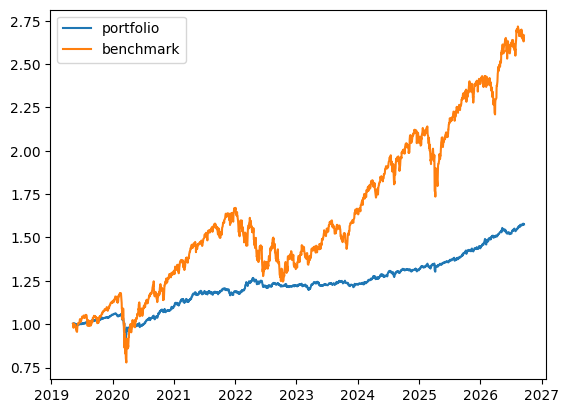

In [ ]:
plt.plot(ptf, label="portfolio")
plt.plot(b, label="benchmark")
plt.legend()

In [ ]:
r = np.load("simulation_2019-05-10 00:00:00_2026-09-18 00:00:00_steps63_sobol2p16_ql0.95_qu0.95_seedrandom.npy")

In [ ]:
Sigma_sim = np.cov(
    r,
    rowvar=False,
    ddof=1
)

ValueError: m has more than 2 dimensions

In [ ]:
sim_returnsn